# 🌫️ Diffusion Models (DDPM)

Welcome to the final frontier of our Generative Models series!

We have covered Autoencoders (compression), VAEs (probabilistic compression), and GANs (adversarial gaming). Now, we explore the architecture that has recently taken the world by storm (powering tools like DALL-E 2, Stable Diffusion, and Midjourney): **Denoising Diffusion Probabilistic Models (DDPM)**.

### The Core Idea: Destruction and Restoration
Diffusion models work on a physics-inspired principle:
1.  **Forward Process (Destruction):** We slowly destroy data by adding noise, step by step, until it is just pure, random Gaussian noise.
2.  **Reverse Process (Creation):** We train a neural network to *learn the reverse*—how to take pure noise and slightly "denoise" it step by step until a clear image emerges.

Unlike GANs, which try to create an image in one go (prone to instability), Diffusion models create images via a slow, iterative, and stable process.

### The Analogy
Imagine a drop of ink falling into a glass of water.
* **Forward:** Over time, the ink diffuses until the water becomes a uniform, cloudy mixture. This is easy to model mathematically.
* **Reverse:** The goal of the model is to reverse time—to watch the cloudy water and calculate exactly where the ink molecules were a millisecond ago, eventually reconstructing the original drop.

## 1. The Math of Diffusion

The process happens over $T$ time steps (e.g., $T=1000$).

### 1.1 The Forward Process ($q$)
We define a noise schedule $\beta_t$ (how much noise to add at each step).
Given an image $x_{t-1}$, we generate $x_t$ by mixing in Gaussian noise $\epsilon$:

$$x_t = \sqrt{1 - \beta_t} x_{t-1} + \sqrt{\beta_t} \epsilon$$

**The Nice Property:** We don't need to loop $t$ times to get a noisy image at step $t$. Using the property of Gaussians, we can jump directly from the original image $x_0$ to any step $t$:

$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$$

Where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t$ is the cumulative product of $\alpha$ up to step $t$.

### 1.2 The Reverse Process ($p$)
We want to calculate $p(x_{t-1} | x_t)$, but this is intractable (we can't know which specific image turned into this noise).
So, we approximate it with a neural network:

$$\mu_\theta(x_t, t) \approx \text{predict the mean of the less noisy image}$$

In practice, Ho et al. (2020) found it's better to predict the **noise** itself. The network asks: "Given this noisy image $x_t$ and time step $t$, what is the noise $\epsilon$ that was added?"

### 1.3 The Objective
The loss function is surprisingly simple. We take an image $x_0$, add random noise $\epsilon$ to it to make $x_t$, and ask the model to predict that noise:

$$\mathcal{L} = || \epsilon - \epsilon_\theta(x_t, t) ||^2$$

It's just Mean Squared Error between the *actual* noise and the *predicted* noise!

## 2. Setup and Hyperparameters

We will implement a simplified DDPM for MNIST.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Configuration
IMAGE_SIZE = 32 # We'll resize MNIST to 32x32 to make U-Net architecture easier (powers of 2)
CHANNELS = 1
TIMESTEPS = 500 # T (Standard is 1000, we use 500 for speed)
BATCH_SIZE = 128
LEARNING_RATE = 2e-4
EPOCHS = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Data Loading ---
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1) # Normalize to [-1, 1] range (Crucial for Diffusion!)
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

Using device: cuda


## 3. The Noise Scheduler

We need a class to handle the math of adding noise (Forward Process) and storing the $\alpha$ and $\beta$ values.

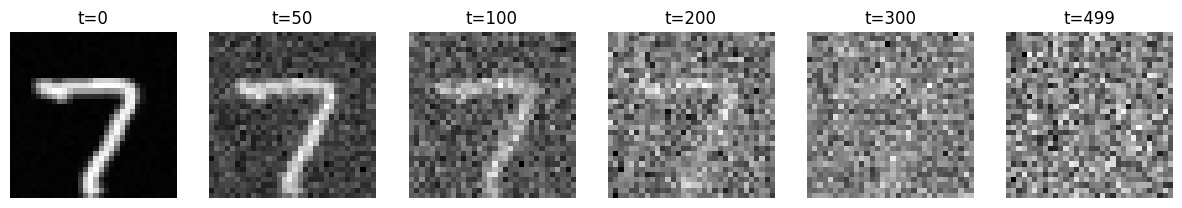

In [3]:
class NoiseScheduler:
    def __init__(self, timesteps=TIMESTEPS, beta_start=1e-4, beta_end=0.02):
        self.timesteps = timesteps

        # Define linear beta schedule
        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)

        # Pre-calculate alpha terms
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # For the reverse process calculations
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)

    def forward_diffusion_sample(self, x_0, t, device):
        """
        Takes an image x_0 and a timestep t and returns x_t (noisy image) + noise.
        """
        noise = torch.randn_like(x_0)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]

        # x_t = sqrt(alpha_bar) * x_0 + sqrt(1 - alpha_bar) * epsilon
        return sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise, noise

# Visualize the Forward Process
scheduler = NoiseScheduler()
x, _ = next(iter(dataloader))
x = x.to(device)

fig, axs = plt.subplots(1, 6, figsize=(15, 3))
steps = [0, 50, 100, 200, 300, 499]

for i, step in enumerate(steps):
    t = torch.tensor([step]).to(device)
    # Get noisy image
    noisy_image, _ = scheduler.forward_diffusion_sample(x[0:1], t, device)

    # Un-normalize for display
    img_display = noisy_image.detach().cpu().squeeze().numpy()
    img_display = (img_display + 1) / 2

    axs[i].imshow(img_display, cmap='gray')
    axs[i].set_title(f"t={step}")
    axs[i].axis('off')
plt.show()

## 4. The Model (U-Net)

The "brain" of a diffusion model is usually a **U-Net**.
Why? Because the task is **image-to-image**: Input is a noisy image, Output is a noise map of the same size. U-Net preserves spatial dimensions perfectly.

**Time Embeddings:** Crucially, the model needs to know *which timestep* $t$ it is currently denoising. A noisy image at $t=10$ looks different from $t=400$. We inject this time information using **Sinusoidal Position Embeddings** (like in Transformers), added to the features inside the U-Net.

In [4]:
# --- Helper Modules ---

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        # First Conv
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Time Embedding Injection
        time_emb = self.relu(self.time_mlp(t))
        # Extend time_emb to match spatial dims: (Batch, Out_Ch, 1, 1)
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Add time channel to features
        h = h + time_emb
        # Second Conv
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)

# --- Simple U-Net ---
import math

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = CHANNELS
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = CHANNELS
        time_emb_dim = 32

        # Time Embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # Initial Projection
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Down Sample
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1], time_emb_dim) \
                    for i in range(len(down_channels)-1)])

        # Up Sample
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True) \
                    for i in range(len(up_channels)-1)])

        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # Embed time
        t = self.time_mlp(timestep)

        # Initial conv
        x = self.conv0(x)

        # Down Path (Store residuals)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)

        # Up Path
        for up in self.ups:
            residual = residuals.pop()
            # Concat skip connection
            x = torch.cat((x, residual), dim=1)
            x = up(x, t)

        return self.output(x)

model = SimpleUNet().to(device)
print("Model initialized.")

Model initialized.


## 5. Training Loop

The training is simple:
1.  Sample a batch of images $x_0$.
2.  Sample random timesteps $t$.
3.  Add noise to create $x_t$.
4.  Ask the U-Net to predict the noise $\epsilon_\theta$.
5.  Calculate MSE Loss between real noise and predicted noise.

In [5]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

print("Starting Training...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for step, (batch, _) in enumerate(dataloader):
        batch = batch.to(device)

        optimizer.zero_grad()

        # 1. Sample random timesteps
        t = torch.randint(0, TIMESTEPS, (BATCH_SIZE,), device=device).long()

        # 2. Add noise (Forward Process)
        x_noisy, noise = scheduler.forward_diffusion_sample(batch, t, device)

        # 3. Predict noise (Reverse Process approximation)
        noise_pred = model(x_noisy, t)

        # 4. Loss
        loss = criterion(noise, noise_pred)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss/len(dataloader):.4f}")

print("Training complete.")

Starting Training...
Epoch 1/10 | Loss: 0.0915
Epoch 2/10 | Loss: 0.0410
Epoch 3/10 | Loss: 0.0362
Epoch 4/10 | Loss: 0.0338
Epoch 5/10 | Loss: 0.0314
Epoch 6/10 | Loss: 0.0303
Epoch 7/10 | Loss: 0.0294
Epoch 8/10 | Loss: 0.0291
Epoch 9/10 | Loss: 0.0283
Epoch 10/10 | Loss: 0.0277
Training complete.


## 6. Inference (Sampling)

This is the "magic" part. We start with pure noise and denoise it loop by loop.

The update rule to go from $x_t$ to $x_{t-1}$ is derived from the math (Ho et al. 2020):

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right) + \sigma_t z$$

Roughly speaking: "Take the current noisy image, subtract the predicted noise (scaled), and add a tiny bit of random noise $z$ back in (Langevin dynamics) to keep the process probabilistic."

Generating images...


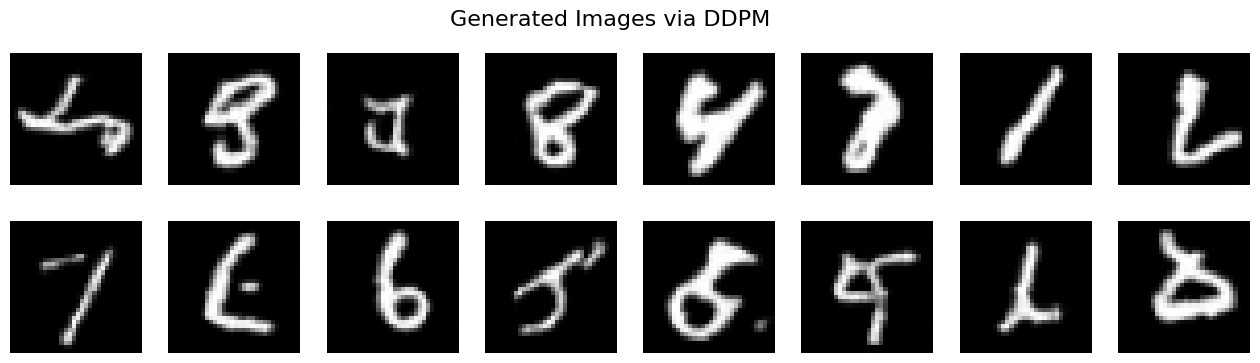

In [6]:
@torch.no_grad()
def sample_ddpm(model, scheduler, n_samples=16):
    model.eval()

    # 1. Start from pure noise (x_T)
    x = torch.randn(n_samples, CHANNELS, IMAGE_SIZE, IMAGE_SIZE).to(device)

    # 2. Iteratively denoise (T down to 0)
    for i in reversed(range(TIMESTEPS)):
        t = torch.tensor([i] * n_samples, device=device).long()

        # Predict noise
        predicted_noise = model(x, t)

        # Get scheduler params
        alpha = scheduler.alphas[t][:, None, None, None]
        alpha_hat = scheduler.alphas_cumprod[t][:, None, None, None]
        beta = scheduler.betas[t][:, None, None, None]

        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x) # No noise at the very last step

        # The Math: x_{t-1} calculation
        x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise

    model.train()

    # Un-normalize to [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x

# --- Run Sampling ---
print("Generating images...")
samples = sample_ddpm(model, scheduler, n_samples=16)

# --- Visualization ---
fig, axs = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    row = i // 8
    col = i % 8
    img = samples[i].permute(1, 2, 0).cpu().numpy()
    axs[row, col].imshow(img.squeeze(), cmap='gray')
    axs[row, col].axis('off')

plt.suptitle("Generated Images via DDPM", fontsize=16)
plt.show()

## 7. Conclusion

You have just implemented a **Denoising Diffusion Probabilistic Model (DDPM)** from scratch!

We saw how:
1.  **Forward Diffusion** slowly destroys data into noise using a fixed schedule.
2.  **Reverse Diffusion** learns to undo this destruction by predicting the noise at each step.
3.  **U-Net** serves as the backbone, predicting noise maps while conditioned on time embeddings.

**Why is this revolutionary?**
Unlike VAEs (which can be blurry) or GANs (which can suffer from mode collapse and training instability), Diffusion models offer stable training and high-quality, diverse results. They are the foundation of modern AI art generation.

This concludes our Generative Models module. You have journeyed from simple compression (AE) to probabilistic generation (VAE), adversarial games (GAN), and finally, iterative denoising (Diffusion).